# Time-strain inversion of the Hess 4D modeled post-stack seismic data 

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import time 
import numpy as np
import matplotlib.pyplot as plt
from pylops.avo.poststack import PoststackLinearModelling
from strainprox.utils import *
from strainprox.functions import strain_jis_cp
from pylops import CausalIntegration
from pylops.basicoperators import Gradient, Diagonal, FirstDerivative
from pyproximal import L21, L2
from matplotlib.colors import ListedColormap, BoundaryNorm
from pyproximal.optimization.primaldual import PrimalDual

import torch
import cupy as cp

## Data loading and visualization

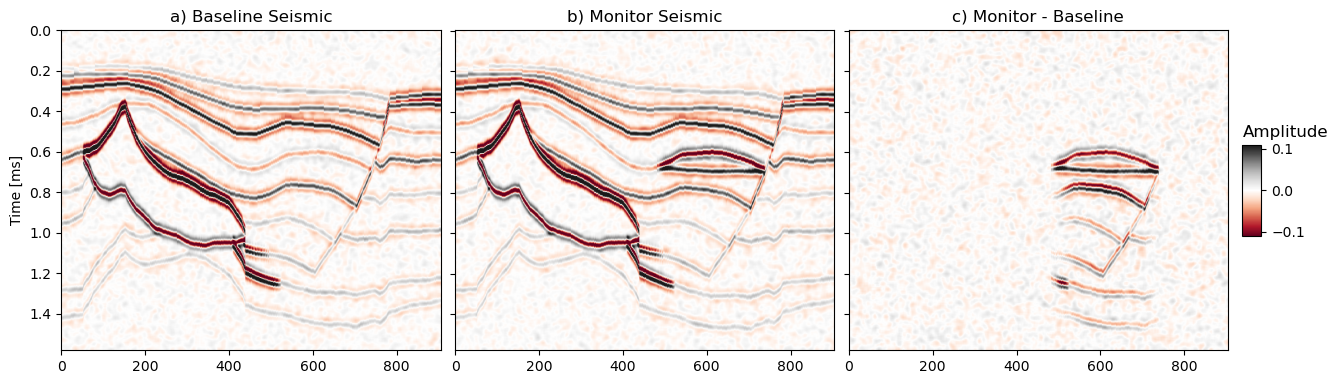

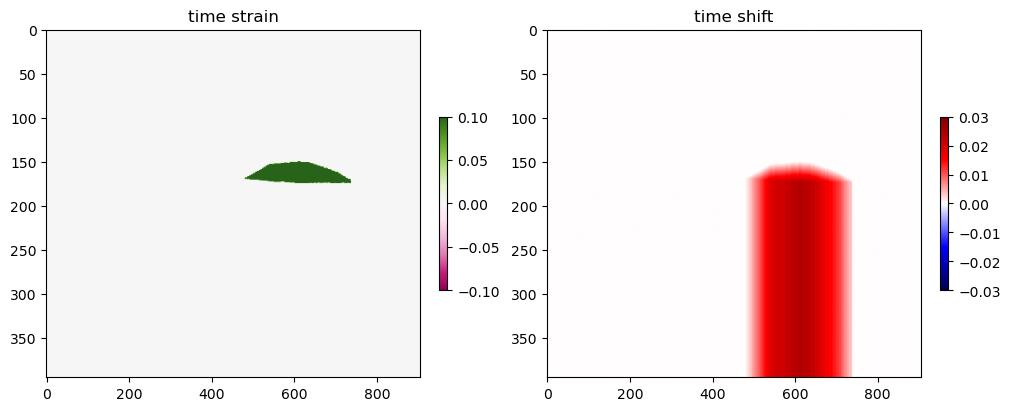

In [3]:
# We load the Hess 4D dataset which contains:
# - Baseline seismic data (d1)
# - Monitor seismic data (d2)
# - Wavelet (wav)
# - Ground truth strain (utrue)

dtype = 'float64'
hess = np.load('../data/Hess/Hess4d_time.npz')
wav = cp.asarray(hess['wav'].astype(np.float32))
d1 = cp.asarray(hess['dn1'].astype(np.float32))
d2 = cp.asarray(hess['dn2'].astype(np.float32))
utrue = cp.asarray(hess['straint'].astype(np.float32))
dims = utrue.shape
dt = 0.004
t = cp.arange(dims[0], dtype='float64') * dt
C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
plotter_4D(d1, d2, dt=dt, ztitle='Time [ms]', type='seismic')
strain_shift(strain=utrue, shift=C*utrue)

## Time-strain inversion with TV regularization

$$
     \Delta u = \argmin_{\Delta u}\Vert d_1(t) - d_2(t+ dt C  u_{i-1}) - dt  J_{d_2} C \Delta u \Vert^2  + \Vert \nabla (\Delta u + u_{i-1})\Vert_{1}
$$

iter 001 | total = 120.284 | data = 61.825 | reg = 58.459 | step = 2.171 | shift_global_rmse = 0.005 | shift_global_mae = 0.002 | shift_roi_rmse = 0.013 | shift_roi_mae = 0.011 | shift_bg_leakage = 0.000 | shift_dice = 0.956 | strain_global_rmse = 0.025 | strain_global_mae = 0.004 | strain_roi_rmse = 0.225 | strain_roi_mae = 0.219 | strain_bg_leakage = 0.003 | strain_dice = 0.395
iter 011 | total = 185.473 | data = 40.049 | reg = 145.424 | step = 0.237 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.001 | shift_dice = 0.897 | strain_global_rmse = 0.021 | strain_global_mae = 0.006 | strain_roi_rmse = 0.163 | strain_roi_mae = 0.158 | strain_bg_leakage = 0.010 | strain_dice = 0.400
iter 021 | total = 204.323 | data = 39.715 | reg = 164.608 | step = 0.089 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.001 | shift_dice = 0.849 | strai

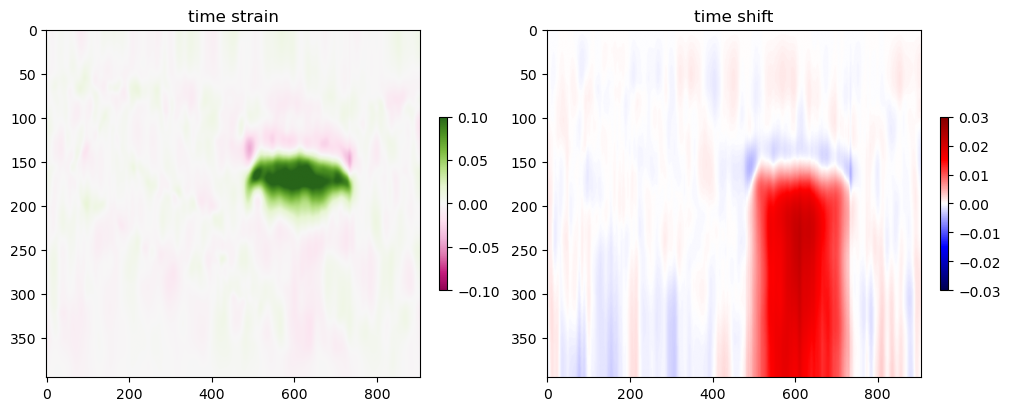

In [26]:
# Algorithm parameters
l2niter = 10    # Number of iterations for L2 proximal solver
pdniter = 10    # Number of iterations for Primal-Dual solver
outeriter = 50  # Number of outer iterations

# Set up operators
C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
D = FirstDerivative(dims=dims, axis=0, sampling=dt, dtype=dtype)
G = PoststackLinearModelling(wav / 2, nt0=dims[0], spatdims=dims[1:])
Dop = Gradient(dims=dims, edge=True, dtype=dtype, kind='forward')
l1 = L21(ndim=len(dims), sigma=1.)

# Initialize variables
ui = cp.zeros(np.prod(dims))
d2i = d2.copy()
gt_shift = C * utrue.reshape(dims)
gt_strain = utrue.reshape(dims)

# Step size parameters
L_approx = 8.
mu = 0.5 # 0.1
tau = 0.99 / (mu * L_approx)


metric_keys = ['global_mae', 'global_rmse', 'roi_mae', 'roi_rmse', 'bg_leakage', 'dice']
history = {k: [] for k in [
    'loss_total', 'loss_data', 'loss_reg',
    *[f'shift_{k}' for k in metric_keys],
    *[f'strain_{k}' for k in metric_keys],
]}

# Run the inversion
start_time = time.perf_counter()
for i in range(outeriter):
    # Calculate data residual
    d = d1.ravel() - d2i.ravel()  
    
    # Set up the Jacobian and operator
    J = Diagonal(D*d2i, dtype=dtype)
    Op = J * C
    
    # Set up the L2 norm
    l2 = L2(Op=Op, b=d, niter=l2niter, warm=True, x0=cp.zeros(np.prod(dims)))
    
    # Gradient on the previous estimate
    gu = Dop * cp.asnumpy(ui)
    l1prec = l1.precomposition(a=1., b=gu)
    l1prec.b = cp.asarray(l1prec.b)
    
    # Update strain using primal-dual algorithm
    du = PrimalDual(
        proxf=l2, 
        proxg=l1prec, 
        A=Dop, 
        tau=tau, 
        mu=mu, 
        theta=1., 
        x0=cp.zeros(np.prod(dims)), 
        niter=pdniter,
        # callback=lambda xx: callbackx(xx.copy(), ui.copy(), utrue.ravel(), xhist, xsnr, xerr), 
        show=False
    )
    # update u
    ui += du
    
    # Update shifted data with new u
    d2i = apply_time_shift_cupy(d=d2, time_shift=C*ui, t=t, dims=dims)
    
    # -------- Evaluate nonlinear objective after update and metrics -----------
    data_term = float(cp.linalg.norm(d - Op * du) ** 2)
    reg_term = float(l1(Dop * ui))
    history['loss_data'].append(data_term)
    history['loss_reg'].append(reg_term)
    history['loss_total'].append(data_term + reg_term)

    pred_shift = C * ui.reshape(dims)
    pred_strain = ui.reshape(dims)
    shift_metrics = compute_all_metrics(pred=pred_shift, gt=gt_shift, alpha=0.05)
    strain_metrics = compute_all_metrics(pred=pred_strain, gt=gt_strain, alpha=0.05)
    for k, val in shift_metrics.items():
        history[f'shift_{k}'].append(val)
    for k, val in strain_metrics.items():
        history[f'strain_{k}'].append(val)

    if i % 10 == 0:
        print(
            f"iter {i + 1:03d} | "
            f"total = {data_term + reg_term:.3f} | "
            f"data = {data_term:.3f} | "
            f"reg = {reg_term:.3f} | "
            f"step = {float(cp.linalg.norm(du)):.3f} | "
            + " | ".join(f"shift_{k} = {val:.3f}" for k, val in shift_metrics.items())
            + " | "
            + " | ".join(f"strain_{k} = {val:.3f}" for k, val in strain_metrics.items())
        )

total_time = time.perf_counter() - start_time
print(f'Total time {total_time / 60:.2f} minutes')

pred_shift_np = cp.asnumpy(pred_shift)
pred_strain_np = cp.asnumpy(pred_strain)
d2i_np = cp.asnumpy(d2i)

# np.savez(
#     '../results/hess/.npz',
#     shift=pred_shift,
#     strain=pred_strain,
#     d2s=d2i,
#     **{k: np.array(v) for k, v in history.items()},
# )

strain_shift(strain=pred_strain_np, shift=pred_shift_np)

## Time-strain inversion with TV regularization and including data term

$$
     \Delta u = \argmin_{\Delta u}\Vert d_1(t) - d_2(t+ dt C  u_{i-1}) - G(u_{i-1}) -  (G + dt  J_{d_2} C) \Delta u \Vert^2  + \Vert \nabla (\Delta u + u_{i-1})\Vert_{1}
$$

iter 001 | total = 417.773 | data = 27.971 | reg = 389.802 | step = 3.184 | shift_global_rmse = 0.006 | shift_global_mae = 0.002 | shift_roi_rmse = 0.014 | shift_roi_mae = 0.012 | shift_bg_leakage = 0.000 | shift_dice = 0.950 | strain_global_rmse = 0.025 | strain_global_mae = 0.005 | strain_roi_rmse = 0.220 | strain_roi_mae = 0.214 | strain_bg_leakage = 0.004 | strain_dice = 0.373
iter 011 | total = 371.720 | data = 19.610 | reg = 352.110 | step = 0.209 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.000 | shift_dice = 0.947 | strain_global_rmse = 0.021 | strain_global_mae = 0.006 | strain_roi_rmse = 0.175 | strain_roi_mae = 0.170 | strain_bg_leakage = 0.008 | strain_dice = 0.327
iter 021 | total = 372.125 | data = 19.281 | reg = 352.845 | step = 0.088 | shift_global_rmse = 0.002 | shift_global_mae = 0.001 | shift_roi_rmse = 0.004 | shift_roi_mae = 0.003 | shift_bg_leakage = 0.000 | shift_dice = 0.953 | stra

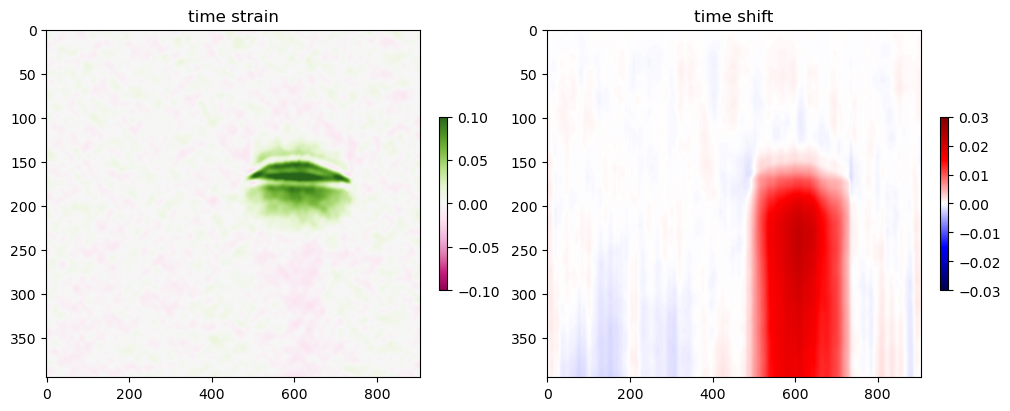

In [12]:
# Algorithm parameters
l2niter = 25    # Number of iterations for L2 proximal solver
pdniter = 10    # Number of iterations for Primal-Dual solver
outeriter = 200  # Number of outer iterations

# Set up operators
C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
D = FirstDerivative(dims=dims, axis=0, sampling=dt, dtype=dtype)
G = PoststackLinearModelling(wav / 2, nt0=dims[0], spatdims=dims[1:])
Dop = Gradient(dims=dims, edge=True, dtype=dtype, kind='forward')
l1 = L21(ndim=len(dims), sigma=1.)

# Initialize variables
ui = cp.zeros(np.prod(dims))
d2i = d2.copy()
gt_shift = C * utrue.reshape(dims)
gt_strain = utrue.reshape(dims)

# Step size parameters
L_approx = 8.
mu = 1.0
tau = 0.99 / (mu * L_approx)


metric_keys = ['global_mae', 'global_rmse', 'roi_mae', 'roi_rmse', 'bg_leakage', 'dice']
history = {k: [] for k in [
    'loss_total', 'loss_data', 'loss_reg', 'iter_time', 'cum_time',
    *[f'shift_{k}' for k in metric_keys],
    *[f'strain_{k}' for k in metric_keys],
]}

# Run the inversion
start_time = time.perf_counter()
for i in range(outeriter):
    iter_start = time.perf_counter()
    # Calculate data residual
    d = d1.ravel() - d2i.ravel() - (G*ui)
    
    # Set up the Jacobian and operator
    J = Diagonal(D*d2i, dtype=dtype)
    Op = G + J * C
    
    # Set up the L2 norm
    l2 = L2(Op=Op, b=d, niter=l2niter, warm=True, x0=cp.zeros(np.prod(dims)))
    
    # Gradient on the previous estimate
    gu = Dop * cp.asnumpy(ui)
    l1prec = l1.precomposition(a=1., b=gu)
    l1prec.b = cp.asarray(l1prec.b)
    
    # Update strain using primal-dual algorithm
    du = PrimalDual(
        proxf=l2, 
        proxg=l1prec, 
        # proxg=l1,
        A=Dop, 
        tau=tau, 
        mu=mu, 
        theta=1., 
        x0=cp.zeros(np.prod(dims)), 
        niter=pdniter,
        # callback=lambda xx: callbackx(xx.copy(), ui.copy(), utrue.ravel(), xhist, xsnr, xerr), 
        show=False
    )
    
    # update u
    ui += du

    # Update shifted monitor data
    d2i = apply_time_shift_cupy(d=d2, time_shift=C*ui, t=t, dims=dims)
    
    # -------- Evaluate nonlinear objective after update and metrics -----------
    iter_elapsed = time.perf_counter() - iter_start
    cum_elapsed = time.perf_counter() - start_time
    history['iter_time'].append(iter_elapsed)
    history['cum_time'].append(cum_elapsed)

    data_term = float(cp.linalg.norm(d - Op * du) ** 2)
    reg_term = float(l1(Dop * ui))
    history['loss_data'].append(data_term)
    history['loss_reg'].append(reg_term)
    history['loss_total'].append(data_term + reg_term)

    pred_shift = C * ui.reshape(dims)
    pred_strain = ui.reshape(dims)
    shift_metrics = compute_all_metrics(pred=pred_shift, gt=gt_shift, alpha=0.05)
    strain_metrics = compute_all_metrics(pred=pred_strain, gt=gt_strain, alpha=0.05)
    for k, val in shift_metrics.items():
        history[f'shift_{k}'].append(val)
    for k, val in strain_metrics.items():
        history[f'strain_{k}'].append(val)

    if i % 10 == 0:
        print(
            f"iter {i + 1:03d} | "
            f"total = {data_term + reg_term:.3f} | "
            f"data = {data_term:.3f} | "
            f"reg = {reg_term:.3f} | "
            f"step = {float(cp.linalg.norm(du)):.3f} | "
            + " | ".join(f"shift_{k} = {val:.3f}" for k, val in shift_metrics.items())
            + " | "
            + " | ".join(f"strain_{k} = {val:.3f}" for k, val in strain_metrics.items())
        )

total_time = time.perf_counter() - start_time
print(f'Total time {total_time / 60:.2f} minutes')

pred_shift_np = cp.asnumpy(pred_shift)
pred_strain_np = cp.asnumpy(pred_strain)
d2i_np = cp.asnumpy(d2i)

strain_shift(strain=pred_strain_np, shift=pred_shift_np)

np.savez(
    '../results/hess/time_strain_tv_g.npz',
    shift=pred_shift,
    strain=pred_strain,
    d2s=d2i,
    **{k: np.array(v) for k, v in history.items()},
)

## Joint-inversion and segmentation

Working with alpha=1.000000,  beta=1.000000,  delta=2.000000
Iteration 0...
f= 5.474137623047012
||v-v_old||_2= 596.5067763850569
||m-m_old||_2= 6.076424918412098
Iteration 1...
f= 8.764877346519706
||v-v_old||_2= 14.68444087193655
||m-m_old||_2= 2.5035108845813996
iter 001 | total = 620.862 | data = 80.953 | reg = 539.909 | step = 2.504 | shift_global_rmse = 0.005 | shift_global_mae = 0.002 | shift_roi_rmse = 0.013 | shift_roi_mae = 0.012 | shift_bg_leakage = 0.000 | shift_dice = 0.931 | strain_global_rmse = 0.024 | strain_global_mae = 0.005 | strain_roi_rmse = 0.206 | strain_roi_mae = 0.198 | strain_bg_leakage = 0.007 | strain_dice = 0.341
Working with alpha=1.000000,  beta=1.000000,  delta=2.000000
Iteration 0...
f= 24.660576871830738
||v-v_old||_2= 596.4661827236627
||m-m_old||_2= 2.75041831324372
Iteration 1...
f= 16.185096738345823
||v-v_old||_2= 16.00229699803459
||m-m_old||_2= 2.865040598315048
Working with alpha=1.000000,  beta=1.000000,  delta=2.000000
Iteration 0...
f= 12.45

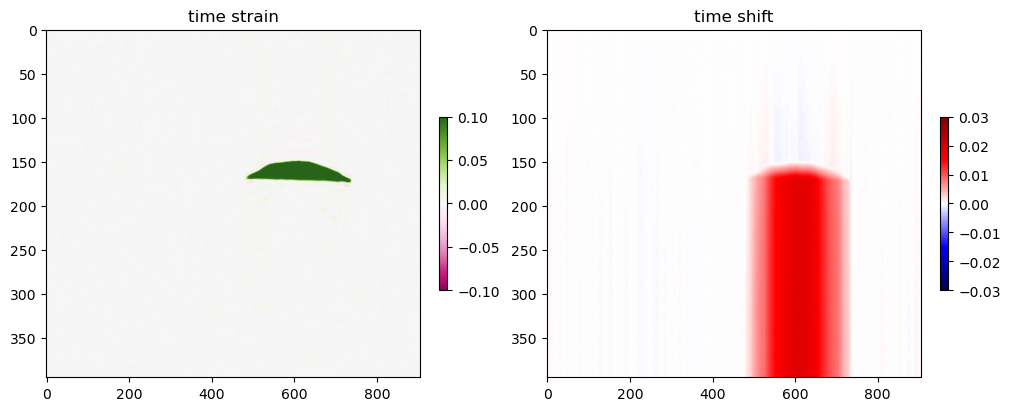

In [6]:
outeriter = 100
l2niter = 20

beta = 1.0
delta = 2.0
alpha = 1.0
niter = 2
pdniter = 10
segmentniter = 20
bisectniter = 10
outdir = '../results/hess'

C = CausalIntegration(dims=dims, axis=0, sampling=dt, dtype=dtype)
D = FirstDerivative(dims=dims, axis=0, sampling=dt, dtype=dtype)
G = PoststackLinearModelling(wav / 2, nt0=dims[0], spatdims=dims[1:])
Dop = Gradient(dims=dims, edge=True, dtype=dtype, kind='forward')
l1 = L21(ndim=len(dims), sigma=1.)

ui = cp.zeros(np.prod(dims))
d2i = d2.copy()
gt_shift = C * utrue.reshape(dims)
gt_strain = utrue.reshape(dims)

cl = cp.array([-0.25, 0., 0.25])

L_approx = 8.
mu = 0.1
tau = 0.99 / (mu * L_approx)
tau_seg = 0.5

metric_keys = ['global_mae', 'global_rmse', 'roi_mae', 'roi_rmse', 'bg_leakage', 'dice']
history = {k: [] for k in [
    'loss_total', 'loss_data', 'loss_reg', 'iter_time', 'cum_time',
    *[f'shift_{k}' for k in metric_keys],
    *[f'strain_{k}' for k in metric_keys],
]}

start_time = time.perf_counter()
for i in range(outeriter):
    iter_start = time.perf_counter()
    d = d1.ravel() - d2i.ravel() - (G * ui)

    J = Diagonal(D * d2i, dtype='float32')
    Op = G + J * C

    du, ui, seg_v, vcl = strain_jis_cp(
        d=d,
        Op=Op,
        x0=cp.zeros(np.prod(dims)),
        ui=ui,
        dims=dims,
        cl=cl,
        alpha=alpha,
        beta=beta,
        delta=delta,
        tau=tau,
        tau_seg=tau_seg,
        mu=mu,
        niter=niter,
        l2niter=l2niter,
        pdniter=pdniter,
        segmentniter=segmentniter,
        bisectniter=bisectniter,
        bregman=True,
        plotflag=False,
        show=False
    )
    # Update shifted data with new u
    d2i = apply_time_shift_cupy(d=d2, time_shift=C * ui, t=t, dims=dims)

    # -------- Evaluate nonlinear objective after update and metrics -----------
    iter_elapsed = time.perf_counter() - iter_start
    cum_elapsed = time.perf_counter() - start_time
    history['iter_time'].append(iter_elapsed)
    history['cum_time'].append(cum_elapsed)

    
    data_term = float(cp.linalg.norm(d - Op * du) ** 2)
    reg_term = float(l1(Dop * ui))
    history['loss_data'].append(data_term)
    history['loss_reg'].append(reg_term)
    history['loss_total'].append(data_term + reg_term)

    pred_shift = C * ui.reshape(dims)
    pred_strain = ui.reshape(dims)
    shift_metrics = compute_all_metrics(pred=pred_shift, gt=gt_shift, alpha=0.05)
    strain_metrics = compute_all_metrics(pred=pred_strain, gt=gt_strain, alpha=0.05)
    for k, val in shift_metrics.items():
        history[f'shift_{k}'].append(val)
    for k, val in strain_metrics.items():
        history[f'strain_{k}'].append(val)

    if i % 10 == 0:
        print(
            f"iter {i + 1:03d} | "
            f"total = {data_term + reg_term:.3f} | "
            f"data = {data_term:.3f} | "
            f"reg = {reg_term:.3f} | "
            f"step = {float(cp.linalg.norm(du)):.3f} | "
            + " | ".join(f"shift_{k} = {val:.3f}" for k, val in shift_metrics.items())
            + " | "
            + " | ".join(f"strain_{k} = {val:.3f}" for k, val in strain_metrics.items())
        )

total_time = time.perf_counter() - start_time
print(f'Total time {total_time / 60:.2f} minutes')

pred_shift_np = cp.asnumpy(pred_shift)
pred_strain_np = cp.asnumpy(pred_strain)
d2i_np = cp.asnumpy(d2i)
vcl_np = cp.asnumpy(vcl)

strain_shift(strain=pred_strain_np, shift=pred_shift_np)

np.savez(
    '../results/hess/time_strain_jis.npz',
    shift=pred_shift,
    strain=pred_strain,
    d2s=d2i,
    vcl=vcl,
    **{k: np.array(v) for k, v in history.items()},
)

In [7]:
vcl_np=np.load('../results/hess/time_strain_jis.npz')['vcl']

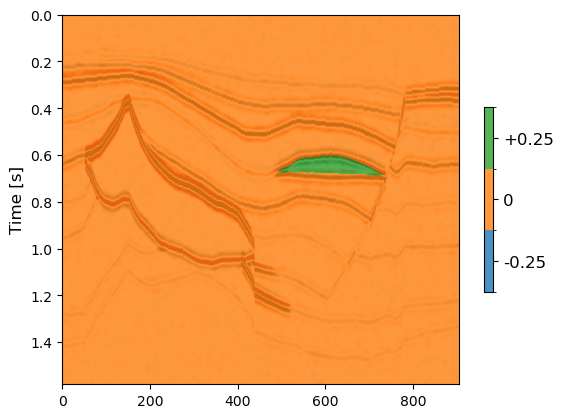

In [40]:
from turtle import title


class_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
cmap = ListedColormap(class_colors)
bounds = [-1.5, -0.5, 0.5, 1.5]  # Boundaries for classes (-1, 0, 1)
norm = BoundaryNorm(bounds, len(class_colors))
# plt.figure(figsize=(8, 8))
plt.imshow(cp.asnumpy(d2), cmap='RdGy',vmin=-0.1, vmax=0.1, extent=(0, dims[1], dims[0]*dt, 0))
plt.ylabel('Time [s]', fontsize=12)
im = plt.imshow(cp.asnumpy(vcl).reshape(dims)-1, cmap=cmap, norm=norm, extent=(0, dims[1], dims[0]*dt, 0), alpha=0.8)
cbar = plt.colorbar(im, boundaries=bounds, ticks=[-1, 0, 1], shrink=0.5)
# Option 1: Increase labelpad (vertical space)
# cbar.set_label(f'Time strain class', fontweight='bold', rotation=0, labelpad=40, loc='top')
cbar.ax.set_yticklabels(['-0.25', '0', '+0.25'], fontsize=12)
# plt.title('Strains segmentation')
plt.axis('tight')
plt.show()